# Spotify Data Analysis

**Author:** Alyssa Leuschner \
**Timeframe:** March 2020 - July 2026 (~ 6.5 Years) \
**Topic:** Analysis of my listening habits \
**Project No.:** 1

In [199]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Exploration & Cleaning 

In [200]:
# Load individual JSON streaming history files
df_2020 = pd.read_json("data/Streaming_History_Audio_2020.json")
df_2021 = pd.read_json("data/Streaming_History_Audio_2021.json")
df_2022_1 = pd.read_json("data/Streaming_History_Audio_2022_1_0101_1907.json")
df_2022_2 = pd.read_json("data/Streaming_History_Audio_2022_2_1907_3112.json")
df_2023_1 = pd.read_json("data/Streaming_History_Audio_2023_1_0101_2704.json")
df_2023_2 = pd.read_json("data/Streaming_History_Audio_2023_2_2704_0708.json")
df_2023_3 = pd.read_json("data/Streaming_History_Audio_2023_3_0708_3112.json")
df_2024_1 = pd.read_json("data/Streaming_History_Audio_2024_1_0101_2005.json")
df_2024_2 = pd.read_json("data/Streaming_History_Audio_2024_2_2005_0111.json")
df_2024_3 = pd.read_json("data/Streaming_History_Audio_2024_3_0111_3112.json")
df_2025_1 = pd.read_json("data/Streaming_History_Audio_2025_1_0101_2305.json")
df_2025_2 = pd.read_json("data/Streaming_History_Audio_2025_2_2305_1509.json")
df_2025_3 = pd.read_json("data/Streaming_History_Audio_2025_3_1509_0512.json")
df_2025_4 = pd.read_json("data/Streaming_History_Audio_2025_4_0512_3112.json")
df_2026_1 = pd.read_json("data/Streaming_History_Audio_2026_1_0101_0207.json")
df_2026_2 = pd.read_json("data/Streaming_History_Audio_2026_2_0207_2507.json")

In [201]:
# Merging individual yearly files into one data set
complete_data = pd.concat(
    [ df_2020,
    df_2021, 
    df_2022_1, df_2022_2, 
    df_2023_1, df_2023_2, df_2023_3,
    df_2024_1, df_2024_2, df_2023_3,
    df_2025_1, df_2025_2, df_2025_3, df_2025_4,
    df_2026_1, df_2026_2],
    axis= 0, join= "inner", ignore_index= True)

In [202]:
complete_data.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode'],
      dtype='str')

In [203]:
# Removing sensitive and irrelevant data (focus on music only)
cleaned_data = complete_data.drop(columns= [
    "ip_addr",
    "conn_country",
    "spotify_track_uri",
    "episode_name",
    "episode_show_name",
    "spotify_episode_uri",
    "audiobook_title",
    "audiobook_uri",
    "audiobook_chapter_uri",
    "audiobook_chapter_title",
    "offline_timestamp",
    "incognito_mode"
])

In [204]:
# Rename certain columns
cleaned_data = cleaned_data.rename(columns={
    "master_metadata_track_name": "track",
    "master_metadata_album_artist_name": "artist",
    "master_metadata_album_album_name": "album"
})

In [205]:
cleaned_data["ts"] = pd.to_datetime(cleaned_data["ts"])

In [206]:
# Looking for missing values
cleaned_data.isna().sum()

ts                0
platform          0
ms_played         0
track           122
artist          122
album           122
reason_start      0
reason_end        0
shuffle           0
skipped           0
offline           0
dtype: int64

In [207]:
# Drop rows where metadata is missing, due to delisted songs
cleaned_data = cleaned_data.dropna(
    subset= [
        "track",
        "artist",
        "album"],
    axis= 0).copy()

In [208]:
# Creating a new column, to filter streams shorter than 30 seconds
cleaned_data["minutes_played"] = (cleaned_data["ms_played"]/ 60000).round(2)
cleaned_data = cleaned_data[cleaned_data["ms_played"] >= 30000].copy()

In [209]:
# Creating a new column, to extract the year
cleaned_data["year"] = cleaned_data["ts"].dt.year

In [210]:
# Check for duplicates
cleaned_data.duplicated().sum()

np.int64(6444)

In [211]:
# Remove duplicates

cleaned_data = cleaned_data.drop_duplicates()
cleaned_data.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis

#### Q1: Which device do I use to listen to music?

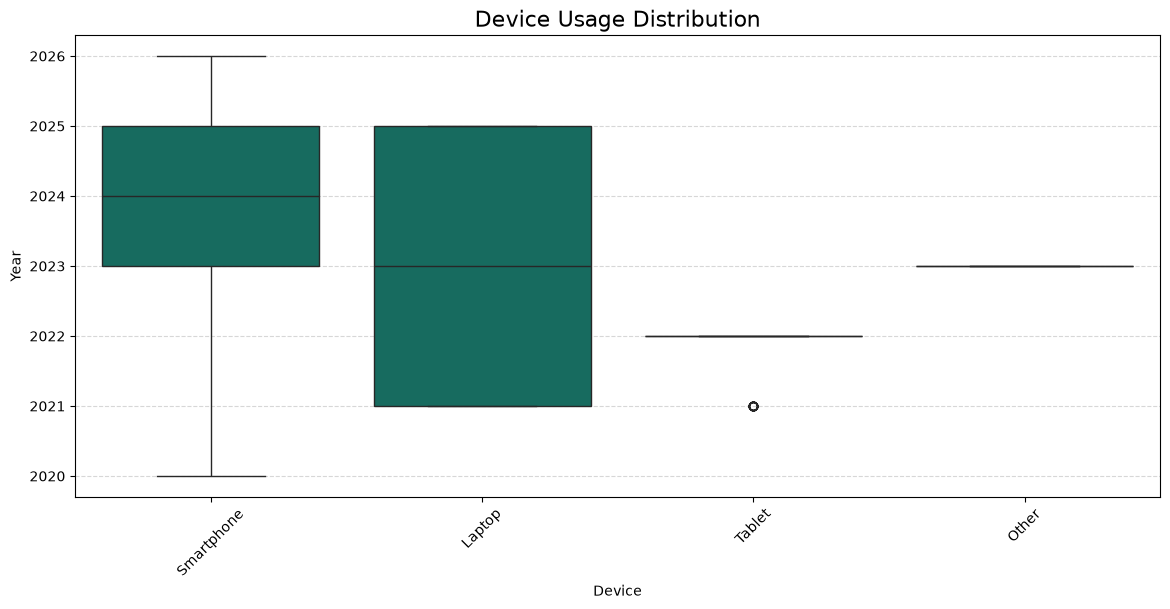

In [212]:
# Define function to simplify the device names
def device(name):

    if "iPhone" in name or "ios" in name:
        return "Smartphone"
    elif "iPad" in name:
        return "Tablet"
    elif "web_player" in name or "osx" in name:
        return "Laptop"
    else:
        return "Other"  


# Creating a new column for devices
cleaned_data["device"] = cleaned_data["platform"].apply(device)


# Creating a boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data= cleaned_data, x= "device", y= "year", color= "#097969")

plt.title("Device Usage Distribution", fontsize= 16)
plt.xlabel("Device")
plt.xticks(rotation=45)
plt.ylabel("Year")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()


In [213]:
cleaned_data["device"].value_counts()

device
Smartphone    85178
Laptop         3448
Tablet          690
Other            34
Name: count, dtype: int64

#### Q2: How has my listening volume developed in the past 7.5 years?

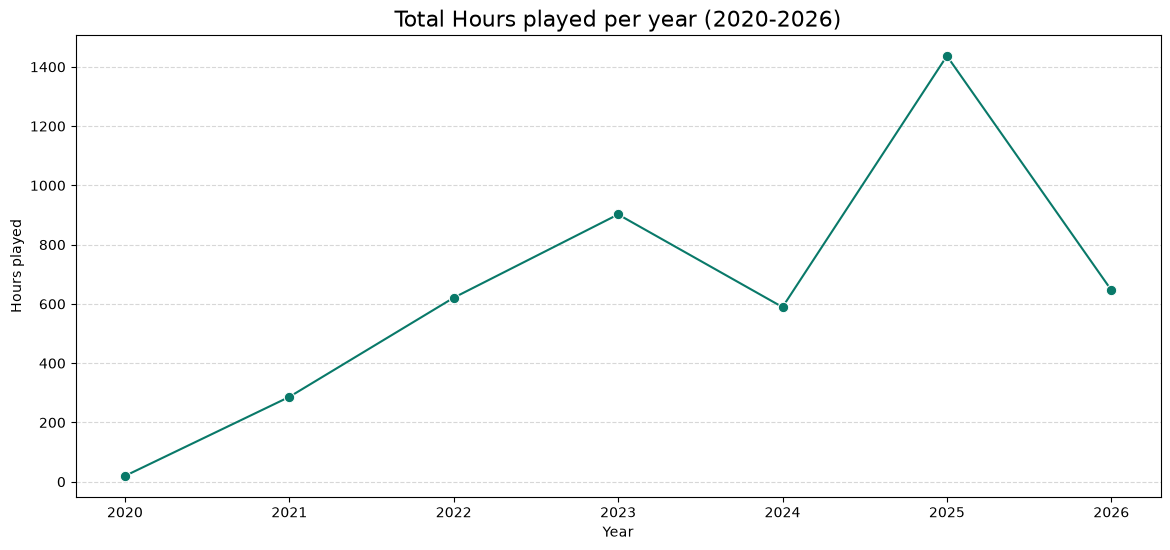

In [214]:
#
yearly_hours = cleaned_data.groupby("year", as_index= False)["minutes_played"].sum()
yearly_hours["hours_played"] = yearly_hours["minutes_played"]/ 60


# Creating a linechart
plt.figure(figsize=(14,6))
sns.lineplot(data= yearly_hours, x= "year", y= "hours_played", color= "#097969", marker= "o", markersize= "7.5", linewidth= "1.5")

plt.title("Total Hours played per year (2020-2026)", fontsize= 16)
plt.xlabel("Year")
plt.ylabel("Hours played")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

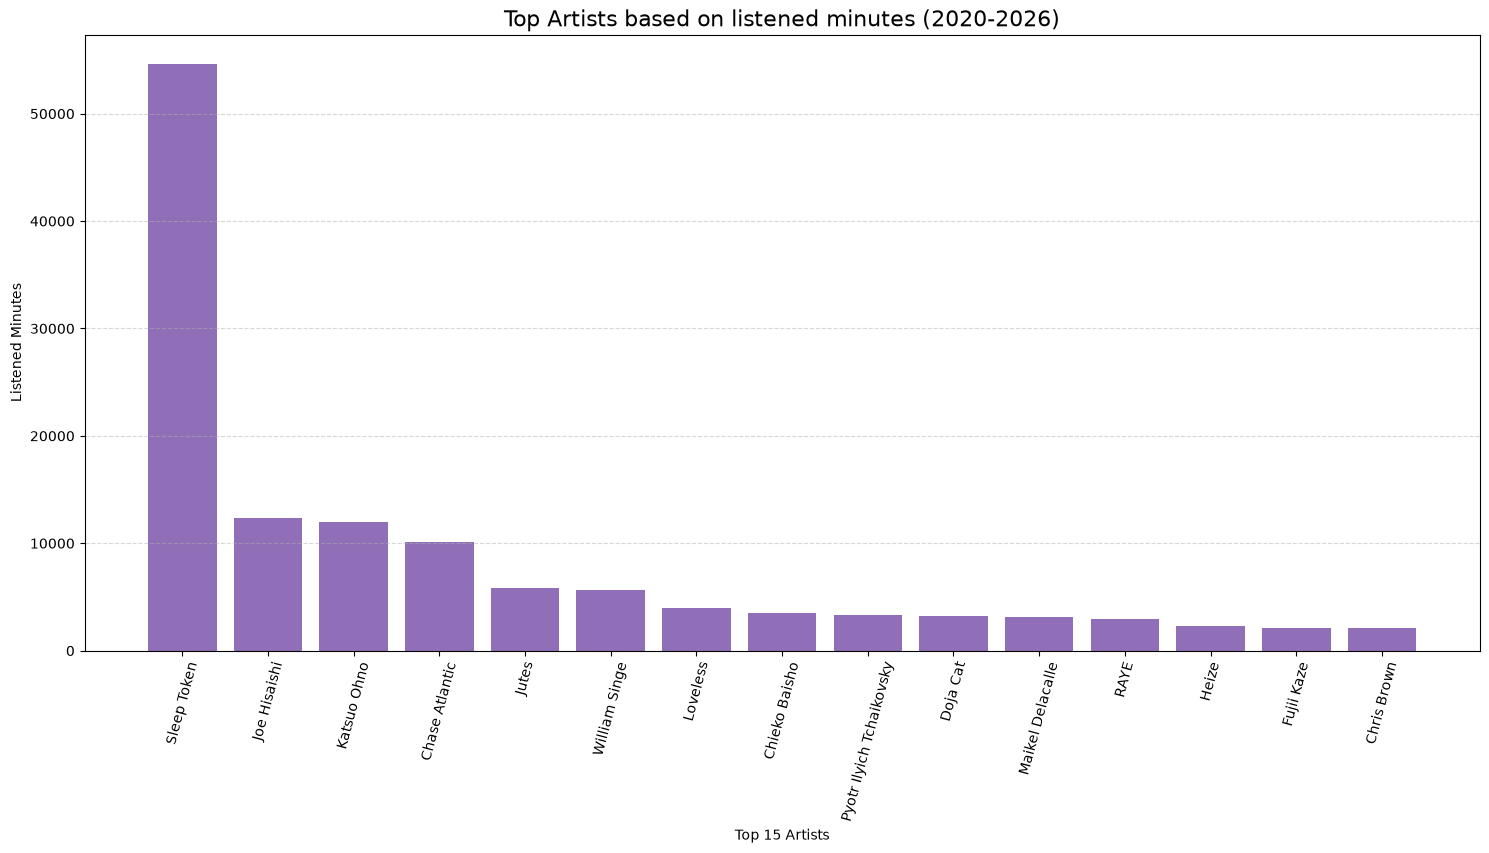

In [215]:
# Aggregate total minutes played per artist and select top 15
top_artists = (cleaned_data.groupby("artist")["minutes_played"].sum().sort_values(ascending= False).head(15))

# Visualise top 15 artists by listened minutes
plt.figure(figsize=(18,8))

plt.bar(x= top_artists.index, height= top_artists.values, color= "#6B3FA0", alpha= 0.75, width= 0.8)

plt.title("Top Artists based on listened minutes (2020-2026)", fontsize= 16)
plt.xlabel("Top 15 Artists")
plt.xticks(rotation= 75)
plt.ylabel("Listened Minutes")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)
plt.show()

#### Q3: Do major life events (e.g. moving to Vienna, switching majors from Humanities to Data Science) correlate with changes in listening habits and if yes, how has my music taste shifted?

In [216]:
# Define seven selected artists and the first time they were listened to (with timestamps)
ft_sleep_token = cleaned_data[cleaned_data["artist"] == "Sleep Token"]["ts"].min()
ft_jutes = cleaned_data[cleaned_data["artist"] == "Jutes"]["ts"].min()
ft_singe = cleaned_data[cleaned_data["artist"] == "William Singe"]["ts"].min()
ft_tchaikovsky = cleaned_data[cleaned_data["artist"] == "Pyotr Ilyich Tchaikovsky"]["ts"].min()
ft_delacalle = cleaned_data[cleaned_data["artist"] == "Maikel Delacalle"]["ts"].min()
ft_heize = cleaned_data[cleaned_data["artist"] == "Heize"]["ts"].min()
ft_hisaishi = cleaned_data[cleaned_data["artist"] == "Joe Hisaishi"]["ts"].min()

In [217]:
# Create a dictionary which combines artist and the first time they were listened to
artist_data = {
    'Artist': ["Sleep Token", "Jutes", "William Singe", "Pyotr Ilyitch Tchaikovsky", "Maikel Delacalle", "Heize", "Joe Hisaishi"],
    'First listened on': [ft_sleep_token, ft_jutes, ft_singe, ft_tchaikovsky, ft_delacalle, ft_heize, ft_hisaishi]
}

# Creata a data frame
artist_data = pd.DataFrame(artist_data).sort_values(by= "Artist").reset_index(drop= True)
artist_data

,Artist,First listened on
0,Heize,2025-01-01 16:32:27+00:00
1,Joe Hisaishi,2021-01-15 13:50:21+00:00
2,Jutes,2024-07-20 12:00:27+00:00
3,Maikel Delacalle,2021-01-01 13:51:52+00:00
4,Pyotr Ilyitch Tchaikovsky,2021-12-20 18:49:05+00:00
5,Sleep Token,2023-06-18 20:49:08+00:00
6,William Singe,2020-11-05 11:31:30+00:00


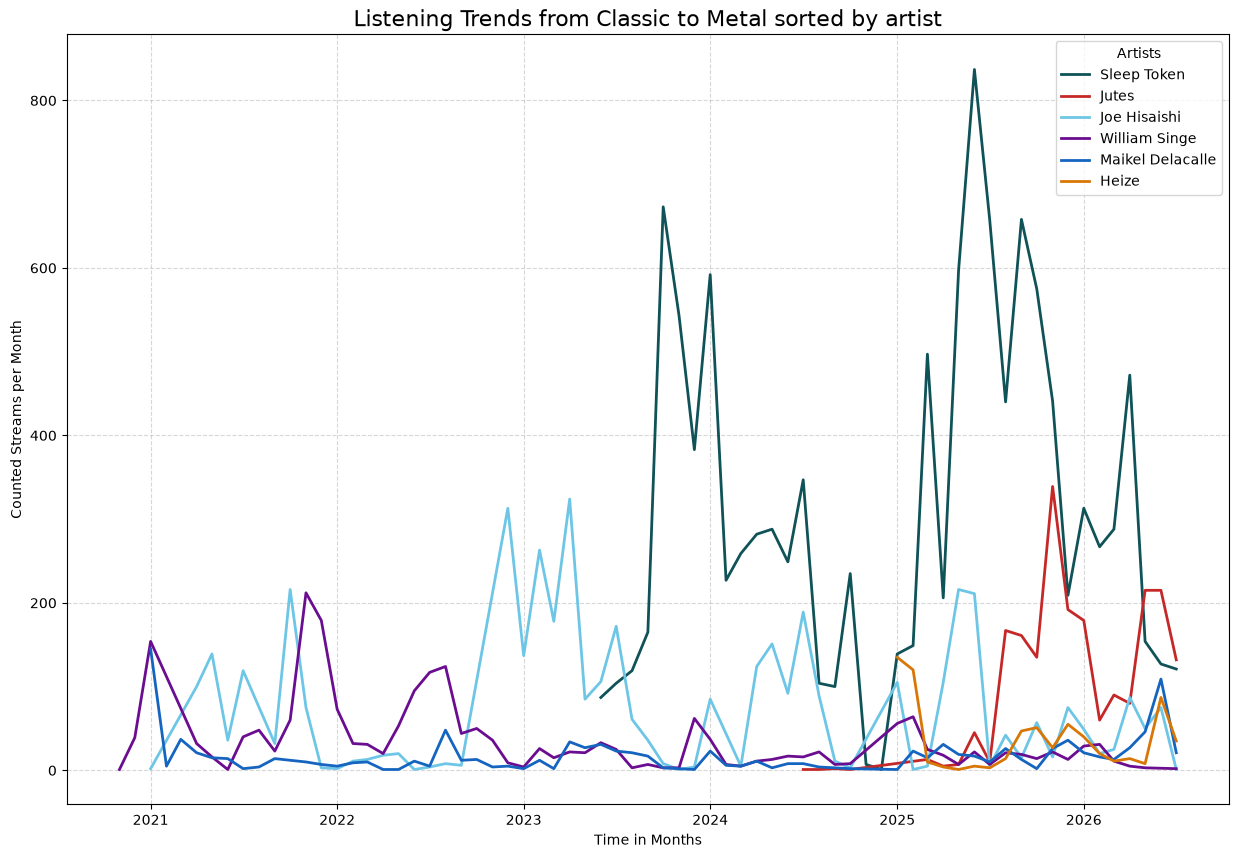

In [218]:
# Select artists and filter them
selected_artists = ["Heize", "Joe Hisaishi", "Jutes", "Maikel Delacalle", "Pyotr Ilyitch Tchaikovsky", "Sleep Token", "William Singe"]
filtered_artists = cleaned_data[cleaned_data["artist"].isin(selected_artists)].copy()


# Determine the timestamps of each song
filtered_artists["month"] = filtered_artists["ts"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

# Determine the number of streams
monthly_streams = filtered_artists.value_counts(["month", "artist"]).reset_index()

# Assign a specific colour to each artist
artist_colours= {
    "Heize": "#D97706",
    "Joe Hisaishi": "#6EC6E6",
    "Jutes": "#C62828",
    "Maikel Delacalle": "#1565C0",
    "Pyotr Ilyitch Tchaikovksy": "#A4774D",
    "Sleep Token": "#0F5257",
    "William Singe": "#6A0D91"

}

# Visualising monthly streaming trends across artists
plt.figure(figsize=(15, 10))
sns.lineplot(data= monthly_streams, x= "month", y= "count", hue= "artist", palette= artist_colours, linewidth= 2)

plt.title("Listening Trends from Classic to Metal sorted by artist", fontsize= 16)
plt.xlabel("Time in Months")
plt.ylabel("Counted Streams per Month")

plt.legend(title= "Artists")
plt.grid(axis= "x", linestyle= "--", alpha= 0.5)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

#### Q4: Are there seasonal genre patterns throughout the year? (months + week)

In [220]:
# Identify my TOP 100 most listened artists of all time
cleaned_data["artist"].value_counts().head(100)

artist
Sleep Token       11912
Katsuo Ohno        4429
Joe Hisaishi       4402
Chase Atlantic     3048
William Singe      2225
                  ...  
BIGBANG             146
BLACKPINK           146
CRO                 146
Kehlani             143
Justin Bieber       143
Name: count, Length: 100, dtype: int64

In [221]:
# Create lists of specific genres
classic_cinematic = ["Joe Hisaishi", "Katsuo Ohno", "Pyotr Ilyich Tchaikovsky", "London Philharmonic Orchestra", "Chieko Baisho", "main character melodies", "Tommee Profitt"]
international_pop = ["Ariana Grande", "Fujii Kaze", "Glee Cast", "Rihanna", "JVKE", "Lady Gaga", "Kevz", "Bruno Mars", "David Guetta", "Demi Lovato", "Pentatonix", "VoicePlay", "Katy Perry", "Pitbull", "George Michael", "James Arthur", "Kevin & Karla", "Michael Schulte", "Dua Lipa", "Tate McRae", "Nelly Furtado", "Walk off the Earth", "Shayne Orok", "Madonna", "Maluma", "ABBA", "Jason Derulo", "Imagine Dragons", "Miley Cyrus", "CRO", "Justin Bieber"]
jazz_swing = ["RAYE", "Michael Bublé", "Riva Taylor"]
k_pop = ["Heize", "LISA", "JENNIE", "Agust D", "EXO","MC MONG", "KAI", "Crush", "TWICE", "MONSTA X", "Stray Kids", "Jung Kook", "BTS", "NCT 127", "BIGBANG", "BLACKPINK"]
rock_metal_alt = ["Sleep Token", "Chase Atlantic", "Jutes", "Loveless", "Dayseeker", "Rain City Drive", "The Word Alive", "STARSET", "SiM", "Our Last Night", "ONE OK ROCK", "Bad Omens", "Fall Out Boy", "Nevertel", "Linked Horizon"]
rnb_rap = ["William Singe", "Doja Cat", "Maikel Delacalle", "Chris Brown", "Timbaland", "The Weeknd", "Chris Grey", "GIMS", "Justin Timberlake", "Empire Cast", "Devvon Terrell", "MEMBA", "T-Pain", "Jay Sean", "Nicki Minaj", "Flo Rida", "Chlöe", "Ty Dolla $ign", "Ciara", "Connor Price", "Cardi B", "Lloyd", "Luniz", "August Alsina", "Yellow Claw", "Lucky Daye", "Amaarae", "Kehlani"]

In [222]:
# Create a dictionary
assign_genre = {}

for artist in classic_cinematic: assign_genre[artist] = "Classic/ Cinematic"
for artist in international_pop: assign_genre[artist] = "International Pop"
for artist in jazz_swing: assign_genre[artist] = "Jazz/ Swing"
for artist in k_pop: assign_genre[artist] = "K-Pop"
for artist in rock_metal_alt: assign_genre[artist] = "Rock/ Metal/ Alternative"
for artist in rnb_rap: assign_genre[artist] = "RnB/ Rap"

# .map() function

cleaned_data["genre"] = cleaned_data["artist"].map(assign_genre). fillna("Other")

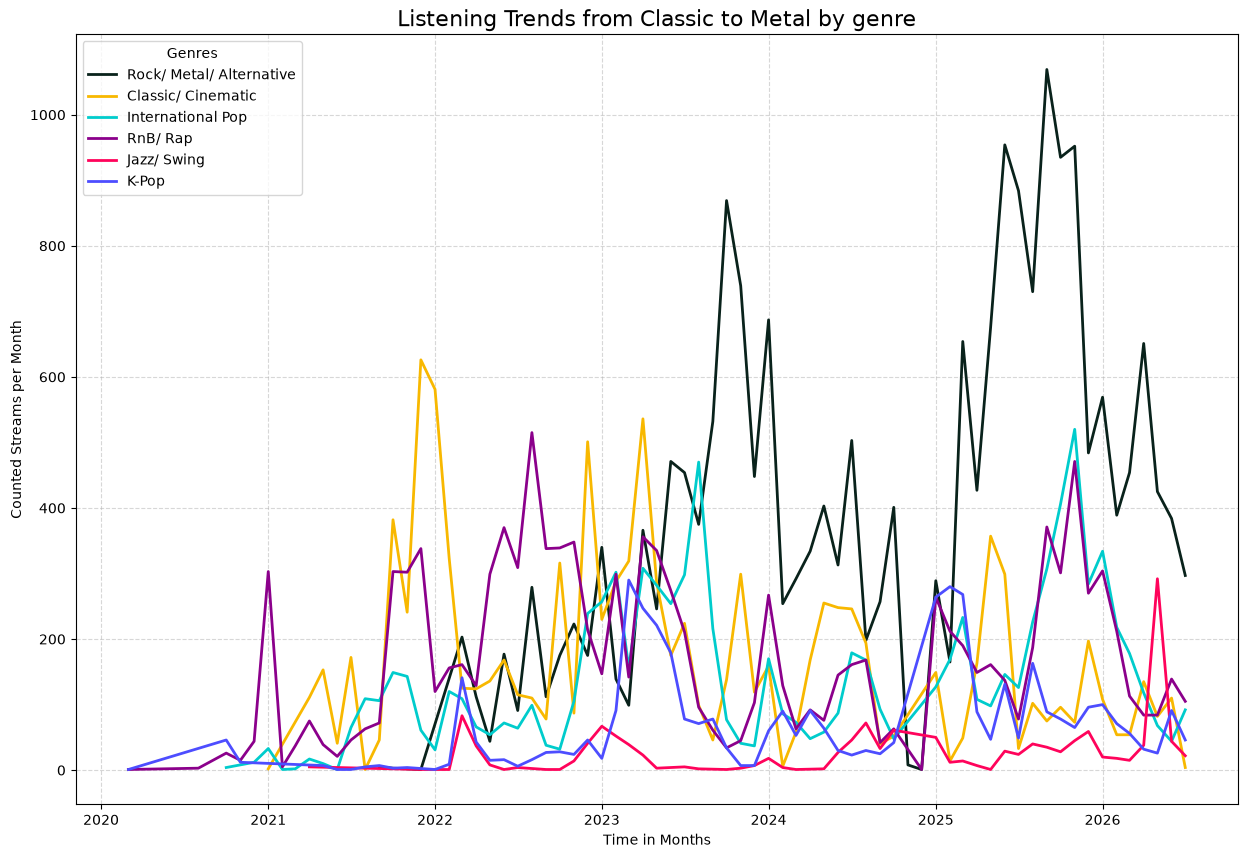

In [223]:
# Select genres and filter them
selected_genres = ["Classic/ Cinematic", "International Pop", "Jazz/ Swing", "K-Pop", "Rock/ Metal/ Alternative", "RnB/ Rap"]
filtered_genres = cleaned_data[cleaned_data["genre"].isin(selected_genres)].copy()

# Determine the timestamps of each song
filtered_genres["month"] = filtered_genres["ts"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

# Determine the number of streams
genre_streams = filtered_genres.value_counts(["month", "genre"]).reset_index()

# Assign a specific colour to each artist
genre_colours= {
    "Classic/ Cinematic": "#F8B800",
    "International Pop": "#00CCCC",
    "Jazz/ Swing": "#FF035B",
    "K-Pop": "#4D4DFF",
    "Rock/ Metal/ Alternative": "#09221B",
    "RnB/ Rap": "#8B008B"

}

# Visualising monthly streaming trends across genres
plt.figure(figsize=(15, 10))
sns.lineplot(data= genre_streams, x= "month", y= "count", hue= "genre", palette= genre_colours, linewidth= 2)

plt.title("Listening Trends from Classic to Metal by genre", fontsize= 16)
plt.xlabel("Time in Months")
plt.ylabel("Counted Streams per Month")

plt.legend(title= "Genres")
plt.grid(axis= "x", linestyle= "--", alpha= 0.5)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

In [224]:
# Create a Pivot Table
pivot_genre = genre_streams.pivot(columns= "genre", index= "month", values= "count").fillna(0).astype(int)

In [225]:
# Create a correlaton matrix based on the "genre" Pivot Table
corr_matrix = pivot_genre.corr()
corr_matrix

genre,Classic/ Cinematic,International Pop,Jazz/ Swing,K-Pop,RnB/ Rap,Rock/ Metal/ Alternative
genre,,,,,,
Classic/ Cinematic,1.000000,0.180820,0.007631,0.126166,0.346945,0.012530
International Pop,0.180820,1.000000,0.160700,0.460820,0.510469,0.554145
Jazz/ Swing,0.007631,0.160700,1.000000,0.126659,0.022129,0.222503
K-Pop,0.126166,0.460820,0.126659,1.000000,0.267738,0.315967
RnB/ Rap,0.346945,0.510469,0.022129,0.267738,1.000000,0.211195
Rock/ Metal/ Alternative,0.012530,0.554145,0.222503,0.315967,0.211195,1.000000


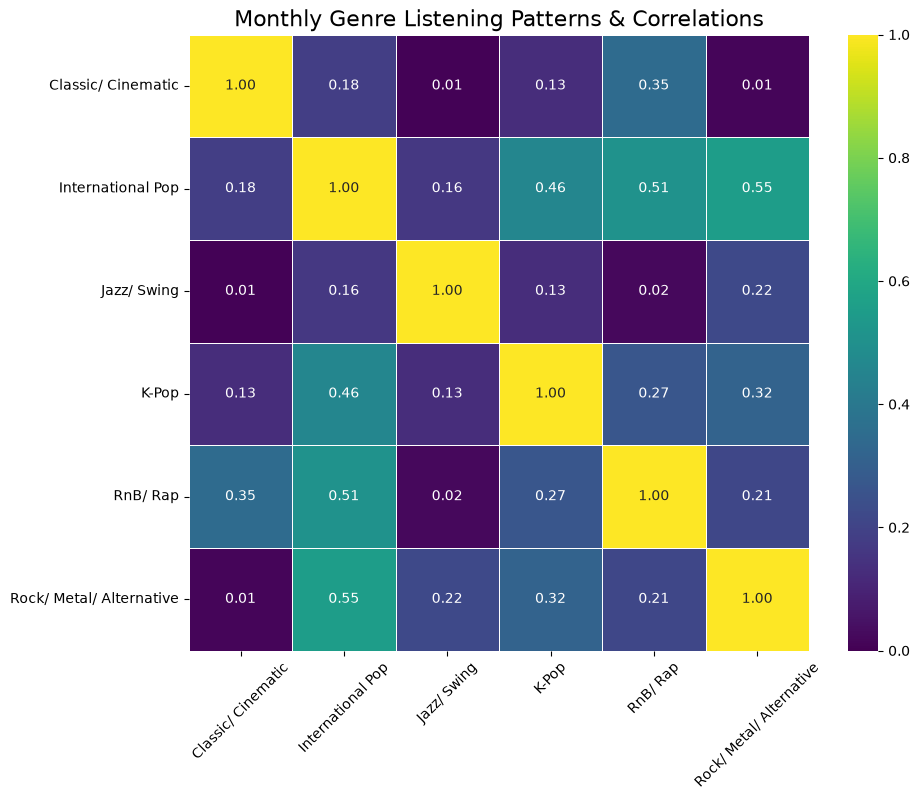

In [226]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data= corr_matrix, vmin= 0, vmax= 1, cmap= "viridis", annot= True, fmt= ".2f", linewidths= 0.5)

plt.title("Monthly Genre Listening Patterns & Correlations", fontsize= 16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation = 45)

plt.show()

#### Q5: Can study sessions be identified in the data (e.g. songs on repeat, specific artist I like to listen to while studying)?